# Stage A — Step-by-step validation of soft cal, TC, fusion, and ETC

This notebook drives a four-step protocol against the persisted Stage A artifacts:

* `bias_corr/soft_calibration.json` — linear `MERRA2 = α·sat + β` per (sensor, region, season)
* `bias_corr/tc_error_variance.json` — Triple-Collocation σ² per (sensor, region, season)
* `merged/YYYY/MM/DD/merged_*.nc` — fused 30-min product (`AOD_merged`) plus per-sensor channels
* `gridded/YYYY/MM/DD/gridded_*.nc` — raw per-sensor grids before soft cal

| Step | Question | Pass condition |
|---|---|---|
| §1a Residual analysis | Are post-cal residuals (sat − MERRA-2) zero-mean and stationary? | normality test passes, no monthly drift > tolerance |
| §1b Spatial variance | Did the cal preserve the satellite's fine structure? | var(calibrated) ≈ var(raw); not collapsed to var(MERRA-2) |
| §2 TC σ² sanity | Negatives? Logical hierarchy? | no negatives; high-fidelity LEO σ² ≤ coarse reanalysis / GEO σ² |
| §3a Seamlessness | Do swath edges show as harsh boundaries? | gradient magnitude at swath edge ≈ background |
| §3b Coverage expansion | Does merged exceed each input's coverage? | merged > best-single-sensor by ≥ 20 pp |
| §4 ETC (McColl 2014) | What is the merged product's correlation with truth ρ̂? | ρ̂_merged ≥ ρ̂ of every input sensor |

Note: §1, §2, §3 are intrinsic — no AERONET. §4 is independent of AERONET too (ETC only needs three collocated retrievals with uncorrelated errors). Compare these results to the AERONET-anchored numbers in `validate_heldout.ipynb` and the per-region tables in `validate_intercomparison.ipynb`.

## 0. Setup

In [1]:
from __future__ import annotations
from datetime import date, datetime, timedelta
from pathlib import Path
from collections import defaultdict
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import netCDF4 as nc
from scipy import stats
from scipy.ndimage import sobel

from config import (
    SOFT_CAL_FILE, TC_VARIANCE_FILE, MERGED_DIR, GRIDDED_DIR,
    LATS, LONS, NLAT, NLON, LAT_MAX, LON_MIN, GRID_RES,
    NORTH_CENTRAL_LAT, CENTRAL_SOUTH_LAT,
    DRY_MONTHS, SEASONS, REGIONS,
    TRAIN_START, TRAIN_END, TEST_START, TEST_END,
    SLOT_MINUTES, SENSOR_CODES,
)
from bias_correction import collect_sat_merra2_pairs
from fusion import load_tc_variance, load_routes
import merra2 as merra2_io

soft_cal  = json.load(open(SOFT_CAL_FILE))
tc_var    = json.load(open(TC_VARIANCE_FILE))
print(f'Soft cal sensors : {list(soft_cal.keys())}')
print(f'TC sensors       : {list(tc_var.keys())}')
print(f'Held-out window  : {TEST_START} → {TEST_END}')
print(f'Train window     : {TRAIN_START} → {TRAIN_END}')

Soft cal sensors : ['himawari_l2', 'himawari_l3', 'modis_maiac', 'viirs_noaa20', 'viirs_snpp']
TC sensors       : ['himawari_l2', 'himawari_l3', 'merra2', 'modis_maiac', 'viirs_noaa20', 'viirs_snpp']
Held-out window  : 2025-01-01 → 2026-04-30
Train window     : 2022-09-01 → 2024-12-31


/home/work1/miniconda3/envs/Airqua_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Soft Calibration Validation

The soft cal harmonises each satellite to MERRA-2 with a per-stratum `MERRA2 = α·sat + β` regression (Ding et al. 2025 form, anchor='merra2' for most strata, with an AERONET fallback for strata where the MERRA-2 gate fails). We need to confirm two things:

1. **Residuals are zero-mean and stationary** — if monthly mean residual drifts seasonally, the single per-season α/β is failing to capture intra-seasonal dynamics, and the cal is leaving structured error in the product.
2. **Spatial variance is preserved** — the cal should shift the mean; it must not blur the satellite down to MERRA-2's ~50 km smoothness.

### 1a. Residual analysis (sat_calibrated − MERRA-2) over time

`collect_sat_merra2_pairs(sensor, start, end)` walks every Stage A2 gridded slot in the window, samples MERRA-2 at the slot's nearest hour, and returns pre-correction `{(region, season): {'sat':…, 'merra2':…}}`. We then apply the persisted `(α, β)` per stratum to get **post-correction residuals**.

We do this on the held-out window (`TEST_START → TEST_END`) — the residuals on training are meaningless by construction (OLS minimises them). Subsample at `STRIDE = 6` (3-h cadence) for speed; raise to 1 for the final headline figure.

In [2]:
STRIDE = 6                                # 6 × 30 min = 3-h cadence; set to 1 for a full pass
RESIDUAL_SENSORS = ('himawari_l2', 'himawari_l3', 'modis_maiac', 'viirs_noaa20', 'viirs_snpp')

def _apply_cal(sat: np.ndarray, fit: dict) -> np.ndarray:
    """Apply persisted α·sat + β if the stratum routes to 'apply'; else identity."""
    if fit is None or fit.get('route') != 'apply':
        return sat
    return fit['alpha'] * sat + fit['beta']

def residual_frames(window_start, window_end, stride=STRIDE):
    """Build per-stratum residual DataFrames keyed by (sensor, region, season).

    Each frame has columns ['sat_raw', 'sat_cal', 'merra2', 'residual'].
    The slot-level time axis is lost in collect_sat_merra2_pairs (it returns
    pooled arrays), so cell 1a-time below re-collects per-month to plot drift.
    """
    out = {}
    for sensor in RESIDUAL_SENSORS:
        pairs = collect_sat_merra2_pairs(sensor, window_start, window_end,
                                          sample_every_n_slots=stride)
        sensor_fits = soft_cal.get(sensor, {})
        for (region, season), d in pairs.items():
            fit = sensor_fits.get(f'{region}|{season}')
            sat_raw = d['sat']
            sat_cal = _apply_cal(sat_raw, fit)
            out[(sensor, region, season)] = pd.DataFrame({
                'sat_raw':  sat_raw,
                'sat_cal':  sat_cal,
                'merra2':   d['merra2'],
                'residual': sat_cal - d['merra2'],
            })
    return out

resid = residual_frames(TEST_START, TEST_END, stride=STRIDE)
summary = pd.DataFrame([
    {'sensor': s, 'region': r, 'season': se,
     'N': len(df),
     'mean':   df['residual'].mean(),
     'median': df['residual'].median(),
     'std':    df['residual'].std(),
     'skew':   stats.skew(df['residual']),
     'kurt':   stats.kurtosis(df['residual'])}
    for (s, r, se), df in resid.items() if len(df) >= 100
])
# summary.sort_values(['sensor', 'region', 'season']).round(4).to_string(index=False)
summary.sort_values(['sensor', 'region', 'season']).round(4)

,sensor,region,season,N,mean,median,std,skew,kurt
2,himawari_l2,central,dry,121428,-0.0180,-0.0109,0.1749,-0.2487,3.317400
4,himawari_l2,central,wet,7879,0.0436,0.0518,0.0688,-0.5568,1.331700
1,himawari_l2,north,dry,99390,-0.0581,-0.0227,0.2522,-0.4484,3.048600
5,himawari_l2,north,wet,16015,0.0590,0.0692,0.1186,-1.4546,8.593200
0,himawari_l2,south,dry,68768,-0.0252,-0.0133,0.1508,-0.4816,3.501200
3,himawari_l2,south,wet,2216,0.0370,0.0492,0.0663,-2.9752,35.996399
8,himawari_l3,central,dry,17785,-0.0192,-0.0082,0.1341,-0.6903,3.271200
6,himawari_l3,north,dry,16903,-0.0084,-0.0102,0.2653,0.4757,4.137100
9,himawari_l3,north,wet,409,0.1159,0.1426,0.1175,-0.5280,0.801200
7,himawari_l3,south,dry,6551,-0.0303,-0.0289,0.1250,-0.1155,9.192400


Now collect the same residuals **per month** so we can see seasonal drift. This is a separate scan — `collect_sat_merra2_pairs` pools across slots, so we slice the held-out window into month-long buckets and run it again.

In [3]:
def _iter_month_starts(start: date, end: date):
    cur = date(start.year, start.month, 1)
    while cur <= end:
        if cur.month == 12:
            nxt = date(cur.year + 1, 1, 1)
        else:
            nxt = date(cur.year, cur.month + 1, 1)
        yield cur, min(nxt - timedelta(days=1), end)
        cur = nxt

monthly_rows = []
for m_start, m_end in _iter_month_starts(TEST_START, TEST_END):
    month_frames = residual_frames(m_start, m_end, stride=STRIDE)
    for (sensor, region, season), df in month_frames.items():
        if len(df) < 50:
            continue
        monthly_rows.append({
            'sensor': sensor, 'region': region, 'season': season,
            'month_start': m_start, 'N': len(df),
            'mean_residual':   df['residual'].mean(),
            'median_residual': df['residual'].median(),
        })
monthly = pd.DataFrame(monthly_rows)
monthly.head()

,sensor,region,season,month_start,N,mean_residual,median_residual
0,himawari_l2,south,dry,2025-01-01,5530,0.056693,0.063412
1,himawari_l2,north,dry,2025-01-01,11266,-0.046098,-0.058793
2,himawari_l2,central,dry,2025-01-01,5841,0.193195,0.166608
3,himawari_l3,north,dry,2025-01-01,1574,-0.034268,-0.045919
4,himawari_l3,south,dry,2025-01-01,260,0.062256,0.051456


### → Your input #1: residual diagnostic

The plan says "residuals should be normally distributed and centered around zero. If you see a heavy skew or seasonal drift, the linear calibration is failing." That's a judgment call: *what test, what threshold, what counts as 'heavy'?* Multiple valid approaches:

* **Normality**: Shapiro-Wilk (powerful, but breaks at N > 5000), D'Agostino's K² (skew + kurt), or just a |skew| / |kurtosis| threshold. With our N ≈ 10⁵ per stratum, formal normality tests will reject everything — a pragmatic threshold on the moments is usually more useful.
* **Drift**: linear regression of monthly mean residual on month-index; flag if slope × n_months > tolerance, or run a Mann-Kendall trend test.
* **Bias**: flag if `|mean| > k · std/√N`.

Fill in `diagnose_stratum` below. Return one dict per stratum with whatever diagnostics + pass/fail flags you trust; the cell after will aggregate them into a table.

In [ ]:
def diagnose_stratum(pooled_residuals: np.ndarray,
                     monthly_means: pd.Series) -> dict:
    """Decide whether a stratum's residuals are 'well-behaved'.

    Parameters
    ----------
    pooled_residuals : 1-D array of (sat_cal - merra2) across the held-out window
    monthly_means    : pd.Series indexed by month_start, the per-month mean residual

    Return a dict with whichever fields you want surfaced, plus a 'pass' bool.
    Suggested keys: {'bias_ok', 'shape_ok', 'drift_ok', 'pass', 'notes'}.
    """
    # TODO — your call:
    #   1. pick a centering tolerance (|mean| < ?)
    #   2. pick a shape rule (|skew| < ?, |kurt - 3| < ?, or a formal test on a subsample)
    #   3. pick a drift rule (regression slope, MK test, range of monthly means, ...)
    #   4. combine into a single pass/fail
    raise NotImplementedError('fill in diagnose_stratum')

rows = []
for (sensor, region, season), df in resid.items():
    if len(df) < 100:
        continue
    mm = (monthly[(monthly['sensor'] == sensor)
                  & (monthly['region'] == region)
                  & (monthly['season'] == season)]
          .set_index('month_start')['mean_residual'])
    diag = diagnose_stratum(df['residual'].values, mm)
    diag.update({'sensor': sensor, 'region': region, 'season': season,
                 'N': len(df)})
    rows.append(diag)
diag_table = pd.DataFrame(rows)
diag_table

NotImplementedError: fill in diagnose_stratum

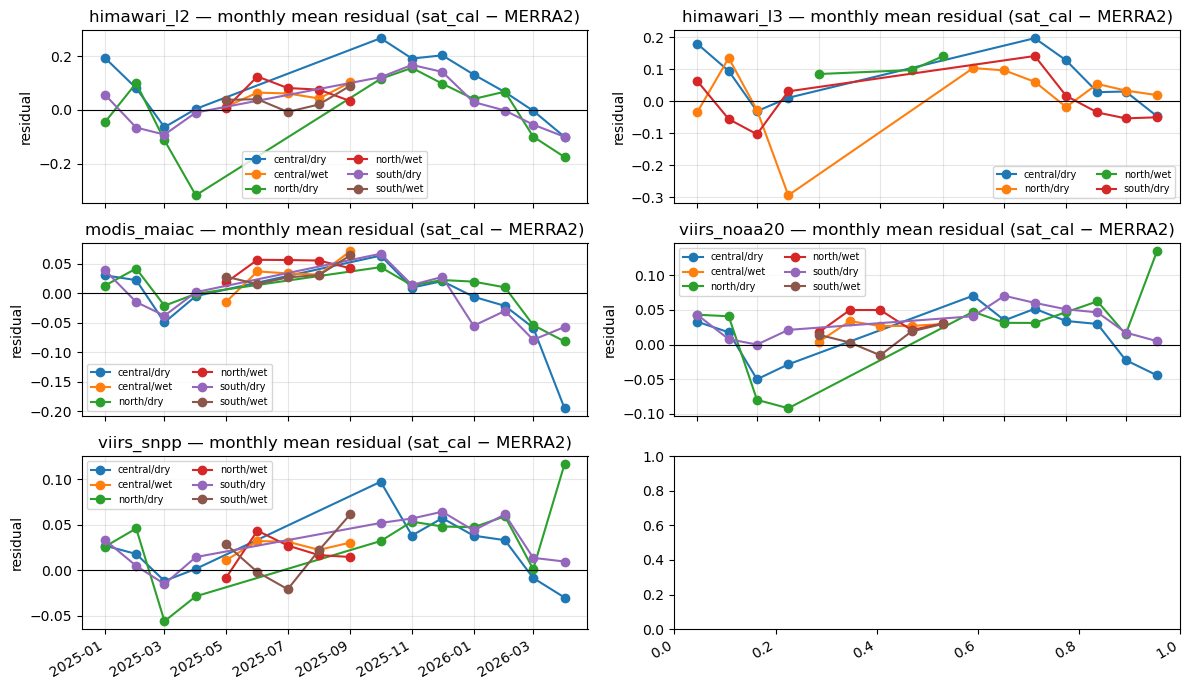

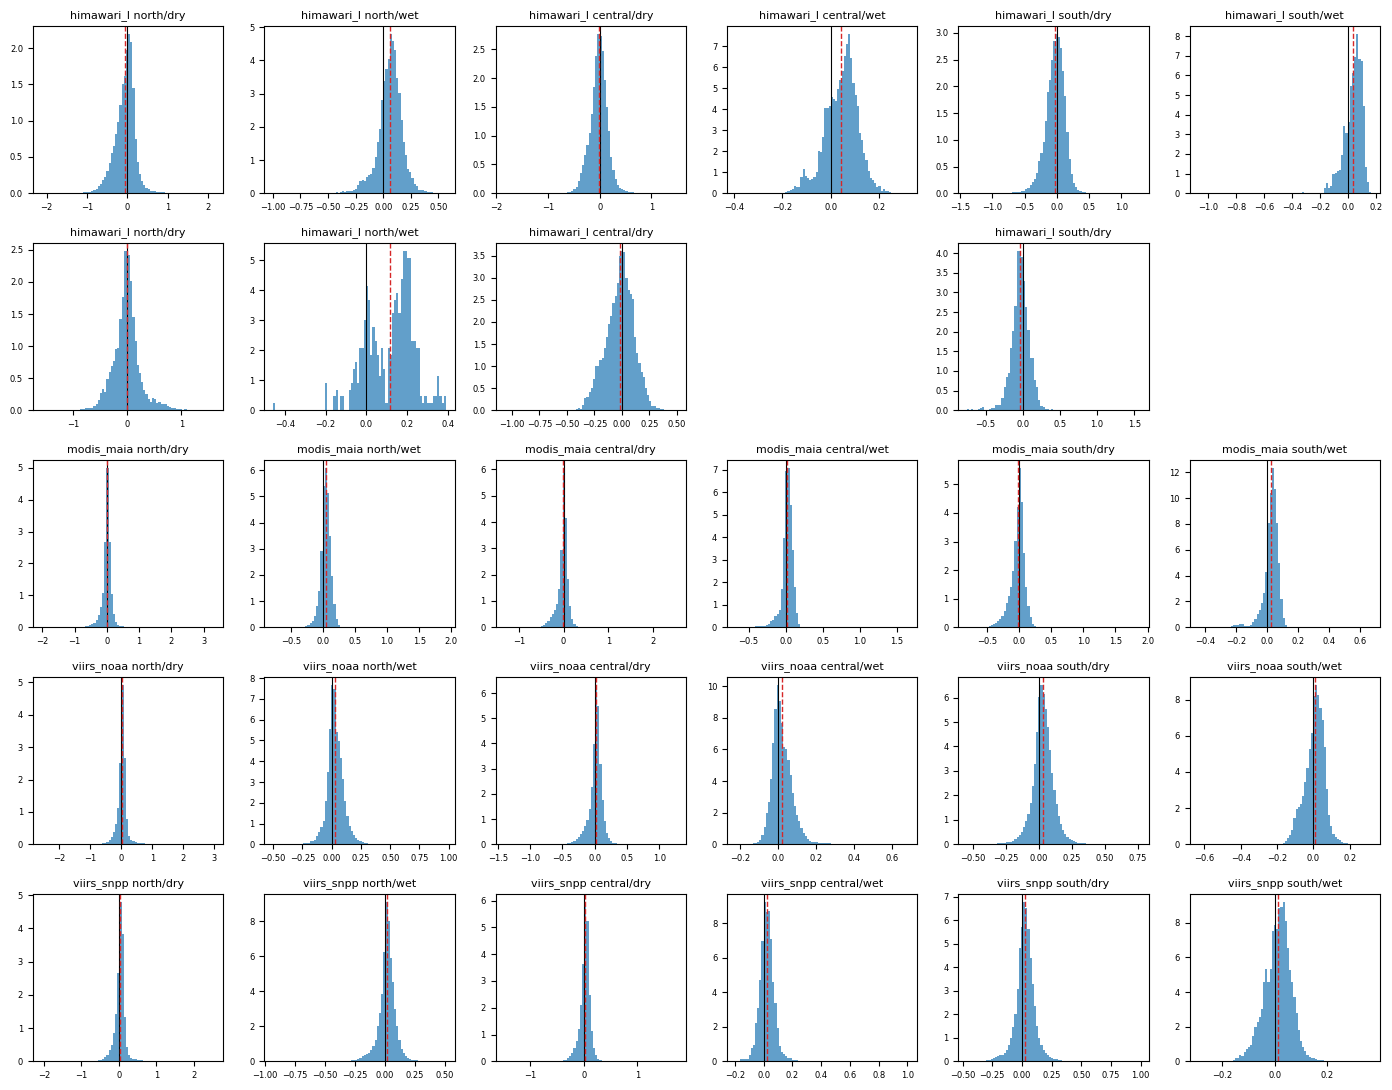

In [7]:
# Visualise: per-sensor monthly mean residual; per-stratum residual histogram
fig, axes = plt.subplots(3, 2, figsize=(12, 7))
for ax, sensor in zip(axes.flat, RESIDUAL_SENSORS):
    sub = monthly[monthly['sensor'] == sensor]
    for (region, season), g in sub.groupby(['region', 'season']):
        ax.plot(g['month_start'], g['mean_residual'], marker='o',
                label=f'{region}/{season}')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'{sensor} — monthly mean residual (sat_cal − MERRA2)')
    ax.set_ylabel('residual')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
fig.autofmt_xdate(); fig.tight_layout(); plt.show()

fig, axes = plt.subplots(len(RESIDUAL_SENSORS), 6, figsize=(14, 2.2 * len(RESIDUAL_SENSORS)),
                          squeeze=False)
strata = [(r, s) for r in REGIONS for s in SEASONS]
for i, sensor in enumerate(RESIDUAL_SENSORS):
    for j, (region, season) in enumerate(strata):
        ax = axes[i][j]
        key = (sensor, region, season)
        if key not in resid or len(resid[key]) < 100:
            ax.set_axis_off(); continue
        r = resid[key]['residual'].values
        ax.hist(r, bins=80, density=True, alpha=0.7)
        ax.axvline(0, color='k', lw=0.8)
        ax.axvline(r.mean(), color='C3', lw=1.0, ls='--')
        ax.set_title(f'{sensor[:10]} {region}/{season}', fontsize=8)
        ax.tick_params(labelsize=6)
fig.tight_layout(); plt.show()

### 1b. Spatial variance preservation

If `var(calibrated) ≈ var(raw)` and both are noticeably larger than `var(MERRA-2_resampled)`, the cal shifted the level without erasing structure — good. If `var(calibrated) → var(MERRA-2)`, the cal has flattened the satellite down to reanalysis smoothness.

We compute variance per slot on the satellite footprint (cells where the sensor reported), then take the median across a sample of slots to be robust to weather. Ratio plotted is `var(calibrated) / var(raw)` per (sensor × region × season).

In [5]:
from bias_correction import _region_codes_2d
from grid import read_gridded_slot

REGION_CODE_NAME = {0: 'north', 1: 'central', 2: 'south'}
REGION_NAME_CODE = {v: k for k, v in REGION_CODE_NAME.items()}
rc2d = _region_codes_2d()

def _slot_iter(start, end, stride):
    d = start
    n = 0
    while d <= end:
        base = datetime(d.year, d.month, d.day)
        for i in range(48):
            if n % stride == 0:
                yield base + timedelta(minutes=i * SLOT_MINUTES)
            n += 1
        d += timedelta(days=1)

VAR_STRIDE = 24                              # one slot per 12 h (cheap)
var_rows = []
for sensor in RESIDUAL_SENSORS:
    accum = defaultdict(lambda: {'raw': [], 'cal': [], 'm2': []})
    sensor_fits = soft_cal.get(sensor, {})
    for slot_utc in _slot_iter(TEST_START, TEST_END, VAR_STRIDE):
        g = read_gridded_slot(slot_utc, sensors=(sensor,))
        if g is None or sensor not in g:
            continue
        sat = g[sensor]['aod_mean']
        m   = merra2_io.get_slot_grid(slot_utc)
        if m is None:
            continue
        season = 'dry' if slot_utc.month in DRY_MONTHS else 'wet'
        for region in REGIONS:
            mask = (rc2d == REGION_NAME_CODE[region]) & np.isfinite(sat) & np.isfinite(m)
            if mask.sum() < 50:
                continue
            sat_v = sat[mask]
            fit   = sensor_fits.get(f'{region}|{season}')
            cal_v = _apply_cal(sat_v, fit)
            accum[(region, season)]['raw'].append(sat_v.var())
            accum[(region, season)]['cal'].append(cal_v.var())
            accum[(region, season)]['m2'].append(m[mask].var())
    for (region, season), d in accum.items():
        if not d['raw']:
            continue
        var_rows.append({
            'sensor': sensor, 'region': region, 'season': season,
            'n_slots': len(d['raw']),
            'var_raw': float(np.median(d['raw'])),
            'var_cal': float(np.median(d['cal'])),
            'var_merra2': float(np.median(d['m2'])),
            'cal_over_raw':    float(np.median(d['cal']) / np.median(d['raw'])),
            'cal_over_merra2': float(np.median(d['cal']) / np.median(d['m2']) if np.median(d['m2']) > 0 else np.nan),
        })
var_df = pd.DataFrame(var_rows).sort_values(['sensor', 'region', 'season'])
var_df.round(4)

,sensor,region,season,n_slots,var_raw,var_cal,var_merra2,cal_over_raw,cal_over_merra2
0,himawari_l2,central,dry,30,0.0439,0.0132,0.0079,0.3016,1.6788
2,himawari_l2,central,wet,19,0.0390,0.0005,0.0003,0.0122,1.6582
1,himawari_l2,north,dry,4,0.0346,0.0158,0.0055,0.4583,2.8719
4,himawari_l2,north,wet,4,0.0638,0.0028,0.0004,0.0441,6.4725
3,himawari_l2,south,wet,16,0.0448,0.0000,0.0012,0.0007,0.0264


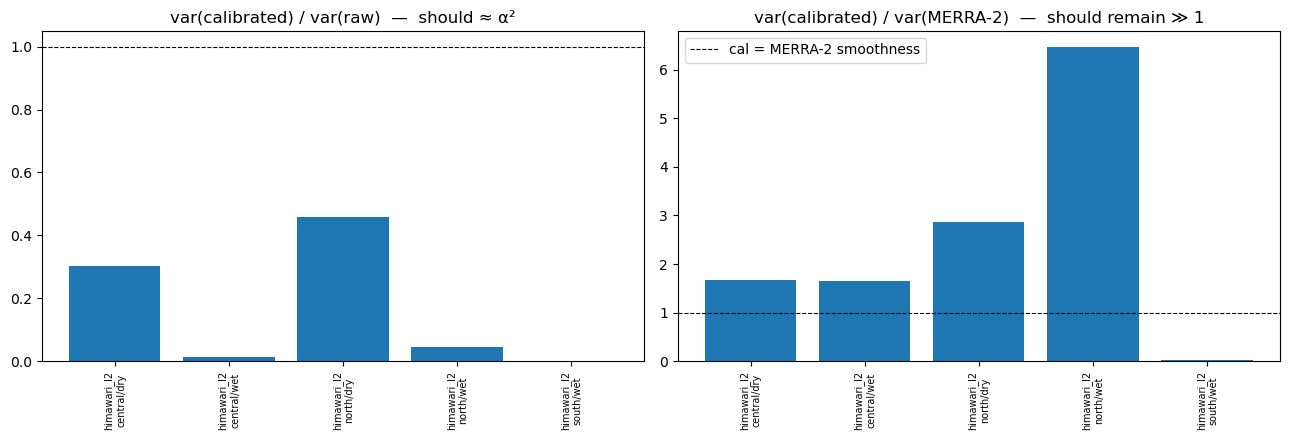

In [6]:
# Visual: variance ratio bars. cal/raw should sit near α² (since var(αX+β)=α²var(X)).
# If you also see cal/merra2 near 1, the satellite has been flattened to reanalysis scale.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
var_df['stratum'] = var_df['sensor'] + '\n' + var_df['region'] + '/' + var_df['season']
axes[0].bar(var_df['stratum'], var_df['cal_over_raw'])
axes[0].axhline(1.0, color='k', ls='--', lw=0.8)
axes[0].set_title('var(calibrated) / var(raw)  —  should ≈ α²')
axes[0].tick_params(axis='x', labelrotation=90, labelsize=7)
axes[1].bar(var_df['stratum'], var_df['cal_over_merra2'])
axes[1].axhline(1.0, color='k', ls='--', lw=0.8, label='cal = MERRA-2 smoothness')
axes[1].set_title('var(calibrated) / var(MERRA-2)  —  should remain ≫ 1')
axes[1].tick_params(axis='x', labelrotation=90, labelsize=7)
axes[1].legend()
fig.tight_layout(); plt.show()

## 2. TC Error Variance Validation

The Triple Collocation σ² in `tc_error_variance.json` is what drives fusion weights at apply time. Two intrinsic checks before we trust them:

1. **No negatives** — `triple_collocation.triple_collocation_variance` already guards against this by flooring at the EE envelope, but we should still confirm no negatives slipped through, and inspect which strata sit *on* the EE floor (those are 'TC couldn't solve, defaulted to envelope').
2. **Logical hierarchy** — high-fidelity LEO sensors (MAIAC, VIIRS) should have lower σ² than coarse-resolution MERRA-2 or geostationary Himawari. If the TC math hands MERRA-2 the smallest σ², the independence-of-errors assumption is violated (e.g. via shared aerosol model heritage or shared collocation grid).

In [8]:
tc_rows = []
for sensor, entries in tc_var.items():
    for stratum, d in entries.items():
        region, season = stratum.split('|')
        tc_rows.append({
            'sensor': sensor, 'region': region, 'season': season,
            'sigma2':       d['sigma2'],
            'n_triplets':   d['n_triplets'],
            'n_colloc':     d['n_collocations'],
        })
tc_df = pd.DataFrame(tc_rows)
tc_df['neg_flag'] = tc_df['sigma2'] < 0
print(f'Negative σ² strata: {int(tc_df["neg_flag"].sum())}')
pivot = tc_df.pivot_table(index='sensor',
                          columns=['region', 'season'],
                          values='sigma2').round(5)
pivot

Negative σ² strata: 0


region        central             north             south        
season            dry      wet      dry      wet      dry     wet
sensor                                                           
himawari_l2   0.00469  0.00014  0.00902  0.00078  0.00451  0.0121
himawari_l3   0.00576      NaN  0.01341  0.01210  0.01210     NaN
merra2        0.01432  0.01020  0.03111  0.01418  0.00957  0.0102
modis_maiac   0.00269  0.00640  0.00343  0.00640  0.00324     NaN
viirs_noaa20  0.00270  0.01210  0.00921  0.01210  0.00332  0.0121
viirs_snpp    0.00408  0.01210  0.00763  0.00453  0.00167     NaN

### → Your input #2: expected sensor ranking

The 'logical hierarchy' check requires *your* prior on sensor skill. Encode below the ranking you'd expect *per region* — the validator will then flag every (region, season) stratum where the observed σ² ordering inverts your prior.

Considerations:
* In NE Asia, MAIAC and VIIRS DB are usually the most accurate; Himawari less so over water; MERRA-2 worst at 0.5° but well-constrained at climate-scale.
* In Vietnam specifically, has the EDA in `EDA/AOD_Comparision/` suggested the central or south region differs? (MAIAC south is known to underperform.)
* Use `None` in slots you don't have a strong prior for — those will be skipped.

Fill the dict, then run the cell after to score it.

In [9]:
# Expected σ² ranking per region (best → worst). 'best' = smallest σ².
# Use sensor keys as they appear in tc_error_variance.json:
#   'himawari_l2', 'himawari_l3', 'modis_maiac', 'viirs_noaa20', 'viirs_snpp', 'merra2'
# Skip a region by setting it to None.
EXPECTED_RANKING = {
    'north':   None,   # TODO — your call: e.g.  ['viirs_noaa20','viirs_snpp','modis_maiac','himawari_l3','himawari_l2','merra2']
    'central': None,   # TODO
    'south':   None,   # TODO
}

def _check_ranking(observed_order, expected_order):
    """Return list of (worse_sensor, better_sensor) violations.

    A violation is a pair where `observed_order` has them swapped vs `expected_order`.
    """
    rank_obs = {s: i for i, s in enumerate(observed_order)}
    rank_exp = {s: i for i, s in enumerate(expected_order)}
    bad = []
    common = [s for s in expected_order if s in rank_obs]
    for i in range(len(common)):
        for j in range(i + 1, len(common)):
            a, b = common[i], common[j]   # a should be better than b
            if rank_obs[a] > rank_obs[b]:
                bad.append((a, b))
    return bad

hier_rows = []
for (region, season), grp in tc_df.groupby(['region', 'season']):
    expected = EXPECTED_RANKING.get(region)
    if not expected:
        continue
    observed = grp.sort_values('sigma2')['sensor'].tolist()
    violations = _check_ranking(observed, expected)
    hier_rows.append({
        'region':   region,
        'season':   season,
        'observed_order': observed,
        'n_violations':   len(violations),
        'violations':     '; '.join(f'{a}>{b}' for a, b in violations) or '—',
    })
pd.DataFrame(hier_rows)

""


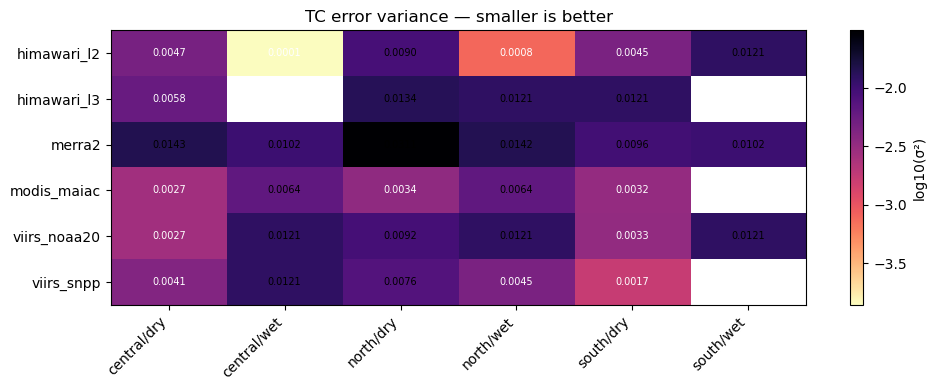

In [10]:
# Visual sanity: log10(σ²) heatmap. Lower (darker) = lower error.
log_pivot = np.log10(pivot.astype(float))
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(log_pivot.values, aspect='auto', cmap='magma_r')
ax.set_xticks(range(len(log_pivot.columns)))
ax.set_xticklabels([f'{r}/{s}' for r, s in log_pivot.columns], rotation=45, ha='right')
ax.set_yticks(range(len(log_pivot.index)))
ax.set_yticklabels(log_pivot.index)
for i in range(log_pivot.shape[0]):
    for j in range(log_pivot.shape[1]):
        v = log_pivot.values[i, j]
        if np.isfinite(v):
            ax.text(j, i, f'{10**v:.4f}', ha='center', va='center',
                    color='w' if v < log_pivot.values[np.isfinite(log_pivot.values)].mean() else 'k',
                    fontsize=7)
fig.colorbar(im, ax=ax, label='log10(σ²)')
ax.set_title('TC error variance — smaller is better')
fig.tight_layout(); plt.show()

## 3. Combined Single Model Validation

Two intrinsic checks on the merged product:

* **Seamlessness** — overlay sensor-presence boundaries on a few sample slot maps and compute the gradient magnitude along the swath edge vs the surrounding interior. A sharp edge means inverse-variance fusion did not blend the LEO swath into the GEO background.
* **Coverage expansion** — count valid pixels per slot for each input sensor, plus the merged product. Merged should dominate.

In [11]:
COVERAGE_STRIDE = 24                       # 12-hourly
MERGED_SENSOR_KEYS = ('AOD_himawari_l2', 'AOD_himawari_l3',
                      'AOD_modis_maiac',
                      'AOD_viirs_snpp', 'AOD_viirs_noaa20')

def _merged_path(slot_utc):
    return MERGED_DIR / slot_utc.strftime('%Y') / slot_utc.strftime('%m') / \
           slot_utc.strftime('%d') / f'merged_{slot_utc.strftime("%Y%m%d_%H%M")}.nc'

cov_rows = []
total = NLAT * NLON
for slot_utc in _slot_iter(TEST_START, TEST_END, COVERAGE_STRIDE):
    f = _merged_path(slot_utc)
    if not f.exists():
        continue
    with nc.Dataset(f) as ds:
        rec = {'slot_utc': slot_utc,
               'season': 'dry' if slot_utc.month in DRY_MONTHS else 'wet'}
        m = np.ma.filled(ds.variables['AOD_merged'][:].astype(np.float32), np.nan)
        rec['cov_merged_pct'] = 100.0 * np.isfinite(m).sum() / total
        for sk in MERGED_SENSOR_KEYS:
            if sk in ds.variables:
                v = np.ma.filled(ds.variables[sk][:].astype(np.float32), np.nan)
                rec[f'cov_{sk}_pct'] = 100.0 * np.isfinite(v).sum() / total
            else:
                rec[f'cov_{sk}_pct'] = 0.0
        cov_rows.append(rec)
cov_df = pd.DataFrame(cov_rows)
cov_means = cov_df.drop(columns=['slot_utc']).groupby('season').mean().T
cov_means['lift_vs_best_single'] = (
    cov_means.loc['cov_merged_pct']
    - cov_means.drop('cov_merged_pct').max(axis=0)
)
cov_means.round(2)

season,dry,wet,lift_vs_best_single
cov_merged_pct,0.11,0.1,NaN
cov_AOD_himawari_l2_pct,0.11,0.1,NaN
cov_AOD_himawari_l3_pct,0.00,0.0,NaN
cov_AOD_modis_maiac_pct,0.00,0.0,NaN
cov_AOD_viirs_snpp_pct,0.00,0.0,NaN
cov_AOD_viirs_noaa20_pct,0.00,0.0,NaN


/tmp/ipykernel_2513455/4170169241.py:52: UserWarning: Adding colorbar to a different Figure <Figure size 1000x400 with 2 Axes> than <Figure size 1800x650 with 13 Axes> which fig.colorbar is called on.
  fig.colorbar(im, ax=axes[0], shrink=0.6, label='AOD_merged')
/tmp/ipykernel_2513455/4170169241.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


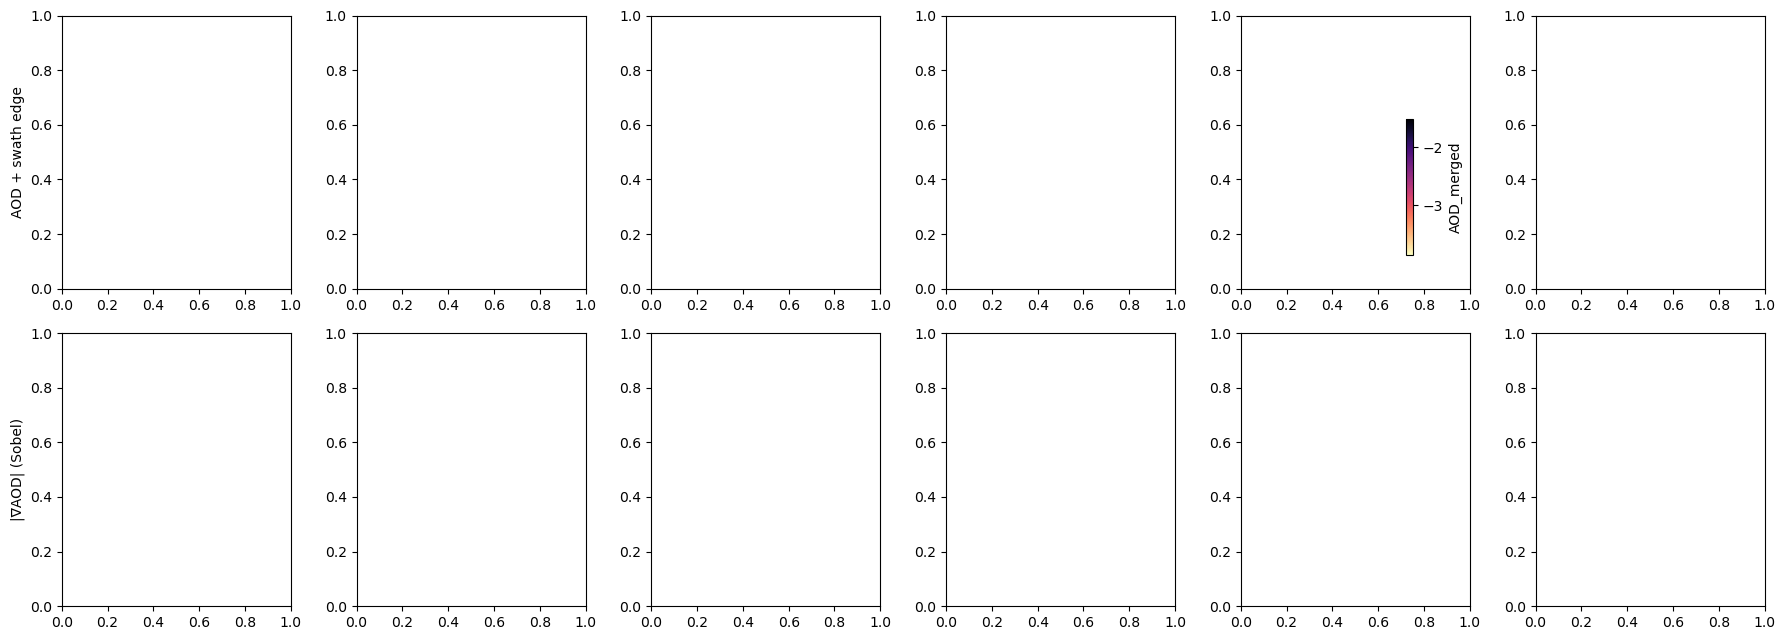

""


In [12]:
# Seamlessness — for a few sample slots known to contain a fresh VIIRS or MAIAC swath,
# (a) show the merged map, (b) outline the swath boundary (where exactly one LEO is
# valid and its neighbour is not), (c) compute |∇AOD_merged| at the edge cells vs
# 5-pixel-interior cells. Edge gradient ≫ interior gradient = harsh seam.

from scipy.ndimage import binary_dilation, binary_erosion

def _swath_edge_mask(valid_mask):
    """Cells on the boundary of a per-sensor swath (true at edge pixels only)."""
    dilated = binary_dilation(valid_mask, iterations=1)
    eroded  = binary_erosion(valid_mask, iterations=1)
    return dilated & ~eroded & valid_mask

SEAM_SAMPLES = 6
candidate_slots = list(_slot_iter(TEST_START, TEST_END, 48))    # daily
selected = []
for s in candidate_slots:
    p = _merged_path(s)
    if not p.exists(): continue
    with nc.Dataset(p) as ds:
        if 'AOD_viirs_noaa20' in ds.variables:
            v = np.ma.filled(ds.variables['AOD_viirs_noaa20'][:].astype(np.float32), np.nan)
            if np.isfinite(v).sum() > 500:
                selected.append((s, p))
    if len(selected) >= SEAM_SAMPLES:
        break

fig, axes = plt.subplots(2, SEAM_SAMPLES, figsize=(3 * SEAM_SAMPLES, 6.5))
report = []
for j, (slot_utc, fp) in enumerate(selected):
    with nc.Dataset(fp) as ds:
        merged = np.ma.filled(ds.variables['AOD_merged'][:].astype(np.float32), np.nan)
        viirs  = np.ma.filled(ds.variables['AOD_viirs_noaa20'][:].astype(np.float32), np.nan)
    valid_viirs = np.isfinite(viirs)
    edge        = _swath_edge_mask(valid_viirs)
    interior    = binary_erosion(valid_viirs, iterations=5)
    # gradient on the merged product (filled NaN to nearest-neighbour mean for sobel)
    filled = np.where(np.isfinite(merged), merged, np.nanmean(merged))
    grad   = np.hypot(sobel(filled, axis=0), sobel(filled, axis=1))
    g_edge = float(np.nanmean(grad[edge]))     if edge.any()     else np.nan
    g_in   = float(np.nanmean(grad[interior])) if interior.any() else np.nan
    report.append({'slot': slot_utc, 'grad_edge': g_edge, 'grad_interior': g_in,
                   'edge_over_interior': (g_edge / g_in) if g_in else np.nan})
    ax_top = axes[0][j]; ax_bot = axes[1][j]
    im = ax_top.imshow(merged, origin='upper', cmap='Spectral_r', vmin=0, vmax=1.5)
    ax_top.contour(valid_viirs, [0.5], colors='k', linewidths=0.6)
    ax_top.set_title(slot_utc.strftime('%Y-%m-%d %H:%MZ'), fontsize=8)
    ax_top.set_xticks([]); ax_top.set_yticks([])
    ax_bot.imshow(grad, origin='upper', cmap='magma')
    ax_bot.contour(valid_viirs, [0.5], colors='c', linewidths=0.6)
    ax_bot.set_xticks([]); ax_bot.set_yticks([])
fig.colorbar(im, ax=axes[0], shrink=0.6, label='AOD_merged')
axes[0][0].set_ylabel('AOD + swath edge')
axes[1][0].set_ylabel('|∇AOD| (Sobel)')
fig.tight_layout(); plt.show()
pd.DataFrame(report).round(4)

## 4. ETC — Extended Triple Collocation (McColl 2014)

ETC recovers each dataset's **correlation with the unknown truth**, ρ̂ᵢ,t, from sample covariances of three collocated retrievals with mutually uncorrelated errors:

$$
\rho_{x,t}^{\,2} = \frac{\mathrm{cov}(x,y)\,\mathrm{cov}(x,z)}{\mathrm{var}(x)\,\mathrm{cov}(y,z)}\quad \text{(and similar for y, z)}
$$

Sign of ρ is the sign of `cov(x, y)` (any of the cross-covs that share the dataset). If the product inside the square root is negative, the triplet's error-independence assumption is violated — flag and move on.

We'll build collocated triplets at the slot+pixel level for the held-out window, using one triplet that includes the merged product:

* **(merged, MAIAC, VIIRS-NOAA20)** — merged is the dataset we're scoring; MAIAC and VIIRS are independent in retrieval algorithm (DB vs DT/MAIAC) and platform.

For comparison we'll also evaluate a sensor-only triplet **(Himawari L2, MAIAC, VIIRS-NOAA20)** — three independent retrievals — so you can read merged's ρ̂ next to the inputs'.

In [ ]:
ETC_STRIDE = 6                              # 3-hourly
ETC_TRIPLETS = {
    'merged_vs_maiac_viirs': ('AOD_merged', 'AOD_modis_maiac', 'AOD_viirs_noaa20'),
    'hima_vs_maiac_viirs':   ('AOD_himawari_l2', 'AOD_modis_maiac', 'AOD_viirs_noaa20'),
}

def collect_triplets(triplet_keys, start, end, stride):
    """Walk merged slots, collect concurrent valid pixels for the three vars.

    Returns dict[(region,season)] -> dict[var -> 1D np.ndarray].
    """
    out = {(r, s): {k: [] for k in triplet_keys} for r in REGIONS for s in SEASONS}
    for slot_utc in _slot_iter(start, end, stride):
        f = _merged_path(slot_utc)
        if not f.exists():
            continue
        try:
            with nc.Dataset(f) as ds:
                if not all(k in ds.variables for k in triplet_keys):
                    continue
                arrs = [np.ma.filled(ds.variables[k][:].astype(np.float32), np.nan)
                        for k in triplet_keys]
        except Exception:
            continue
        valid = np.ones_like(arrs[0], dtype=bool)
        for a in arrs:
            valid &= np.isfinite(a)
        if not valid.any():
            continue
        season = 'dry' if slot_utc.month in DRY_MONTHS else 'wet'
        for region in REGIONS:
            mask = valid & (rc2d == REGION_NAME_CODE[region])
            if not mask.any():
                continue
            for k, a in zip(triplet_keys, arrs):
                out[(region, season)][k].append(a[mask])
    final = {}
    for key, d in out.items():
        if all(d[k] for k in triplet_keys):
            final[key] = {k: np.concatenate(d[k]) for k in triplet_keys}
    return final

triplets = {name: collect_triplets(keys, TEST_START, TEST_END, ETC_STRIDE)
            for name, keys in ETC_TRIPLETS.items()}
for name, d in triplets.items():
    print(f'{name}: {len(d)} (region, season) cells')
    for (r, s), arrs in d.items():
        n = len(next(iter(arrs.values())))
        print(f'  {r:7s}/{s:3s}  N={n:>8d}')

### → Your input #3: implement ETC

Fill in `extended_triple_collocation(x, y, z)` below using McColl et al. (2014, GRL) — the PDF you have in `AOD_map/Geophysical Research Letters - 2014 - McColl - Extended triple collocation…pdf`. Things to settle:

1. The three ρ²_i,t formulae (one per dataset). Recover sign of ρ from `cov(x, y)` (or `cov(x, z)` — they should agree if assumptions hold; you can use that as a sanity check).
2. The σ²_i estimator (Stoffelen 1998 form) — for cross-reference with `tc_error_variance.json`. Should match within sampling noise on independent triplets.
3. How to handle the **failure case** when the product inside √ is negative. Per McColl, this means triplet errors are not independent. Options: return NaN with a `tripled_failed=True` flag, OR raise.

Return a dict like `{'rho_x': …, 'rho_y': …, 'rho_z': …, 'sigma2_x': …, 'sigma2_y': …, 'sigma2_z': …, 'triplet_failed': bool, 'N': int}`.

In [ ]:
def extended_triple_collocation(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> dict:
    """McColl et al. 2014 — ρ_i,t and σ²_i from three collocated datasets.

    Assumes errors are mutually uncorrelated and uncorrelated with truth.
    All three inputs must be 1-D arrays of equal length covering the same
    collocations.
    """
    # TODO — your call (see the McColl paper):
    #   var/cov: var(x)=Cxx, cov(x,y)=Cxy, etc.
    #   ρ²_x,t = Cxy · Cxz / (Cxx · Cyz)        (analogous for y, z)
    #   σ²_x   = Cxx − Cxy · Cxz / Cyz          (analogous for y, z)
    #   sign:  ρ_x = sign(Cxy) · sqrt(max(ρ²_x,t, 0))
    raise NotImplementedError('implement ETC from McColl 2014')

etc_rows = []
for triplet_name, region_data in triplets.items():
    var_keys = ETC_TRIPLETS[triplet_name]
    for (region, season), arrs in region_data.items():
        x, y, z = arrs[var_keys[0]], arrs[var_keys[1]], arrs[var_keys[2]]
        if len(x) < 200:
            continue
        try:
            r = extended_triple_collocation(x, y, z)
        except NotImplementedError:
            print('Implement extended_triple_collocation above, then re-run this cell.')
            break
        etc_rows.append({
            'triplet': triplet_name,
            'region':  region,
            'season':  season,
            'N':       int(r.get('N', len(x))),
            f'rho_{var_keys[0]}':    r['rho_x'],
            f'rho_{var_keys[1]}':    r['rho_y'],
            f'rho_{var_keys[2]}':    r['rho_z'],
            f'sigma2_{var_keys[0]}': r['sigma2_x'],
            f'sigma2_{var_keys[1]}': r['sigma2_y'],
            f'sigma2_{var_keys[2]}': r['sigma2_z'],
            'triplet_failed':        r.get('triplet_failed', False),
        })
    else:
        continue
    break
etc_df = pd.DataFrame(etc_rows)
etc_df.round(3)

In [ ]:
# Cross-check: ETC σ² estimates from the held-out window vs the persisted training
# table in tc_error_variance.json. These won't match exactly (different windows,
# different triplet) but the ordering should agree.
if not etc_df.empty:
    cross = []
    for _, r in etc_df.iterrows():
        triplet_keys = ETC_TRIPLETS[r['triplet']]
        for k in triplet_keys:
            sensor = k.replace('AOD_', '')
            persisted = tc_var.get(sensor, {}).get(f"{r['region']}|{r['season']}", {})
            cross.append({
                'triplet': r['triplet'],
                'region':  r['region'],
                'season':  r['season'],
                'sensor':  sensor,
                'sigma2_etc_heldout':    r[f'sigma2_{k}'],
                'sigma2_persisted_train': persisted.get('sigma2', np.nan),
                'n_persisted':            persisted.get('n_collocations', 0),
            })
    cross_df = pd.DataFrame(cross).drop_duplicates(
        subset=['triplet','region','season','sensor'])
    cross_df.round(5)

## Summary — what passed, what failed

After running all sections, cross-check against the matching cells:

| Step | Look at | Pass evidence |
|---|---|---|
| §1a | `diag_table`, monthly drift plot | every stratum row has `pass=True` |
| §1b | `var_df`, ratio bars | `cal_over_merra2` ≫ 1 everywhere |
| §2 | `tc_df['neg_flag']`, hierarchy table | no negatives; `n_violations` = 0 in every region you encoded |
| §3a | `report` table | `edge_over_interior` ≤ ~2× across the sample slots |
| §3b | `cov_means` | `lift_vs_best_single` ≥ 20 (pp) in both seasons |
| §4 | `etc_df` | `rho_AOD_merged` ≥ `rho_AOD_*` in the merged triplet for every region/season |

Any failures should be cross-referenced with `validate_heldout.ipynb` §4 (AERONET gate) and `validate_intercomparison.ipynb` §1a (R² lift) — failures here often surface as soft signals there.